<a href="https://colab.research.google.com/github/Abdullah-Farooq292/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Abdullah-Farooq292/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Ranked action queue built from the Week-6 model score on the honest (client-grouped) held-out test set. Each page gets a reason code explaining why it's flagged, based on which features drove its score — not just the raw number. Note: because the tree has only max_depth=4, many pages share an identical decline_score (the tree can't distinguish within a leaf). A secondary tiebreak (staleness + age) is used to order tied pages, and reason codes include actual feature values so tied pages still read differently to a human reviewer. Reason codes show the exact decision path each page took through the tree (each split condition it passed, with its actual value). Pages sharing a leaf show the same path, but their reported values still differ — the full path preserves traceability even when the model's raw score can't distinguish pages further.

In [12]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

# Use the tree's own decision path to explain each prediction — not guessed thresholds
from sklearn.tree import _tree

def get_decision_path_reason(tree_model, feature_names, X_row):
    tree_ = tree_model.tree_
    feature_name = [feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!"
                     for i in tree_.feature]
    node = 0
    reasons = []
    while tree_.feature[node] != _tree.TREE_UNDEFINED:
        name = feature_name[node]
        threshold = tree_.threshold[node]
        value = X_row[name]
        if value <= threshold:
            reasons.append(f"{name} <= {threshold:.1f} (actual: {value:.1f})")
            node = tree_.children_left[node]
        else:
            reasons.append(f"{name} > {threshold:.1f} (actual: {value:.1f})")
            node = tree_.children_right[node]
    return "; ".join(reasons)

queue = X_test.copy()
queue["content_id"] = df.iloc[test_idx]["content_id"].values
queue["decline_score"] = scores
queue["reason_code"] = queue.apply(
    lambda row: get_decision_path_reason(tree, features, row), axis=1)

queue["tiebreak"] = queue["days_since_last_update"] + queue["content_age_days"]
queue = queue.sort_values(["decline_score", "tiebreak"], ascending=[False, False]).reset_index(drop=True)
queue["rank"] = queue.index + 1

print("Top 10 ranked actions:")
print(queue[["rank", "content_id", "decline_score", "reason_code"]].head(10).to_string(index=False))

print(f"\nUnique decline_score values in test set: {queue['decline_score'].nunique()} "
      f"(out of {len(queue)} pages)")


Top 10 ranked actions:
 rank           content_id  decline_score                                                                                                                                       reason_code
    1 content_b63ea08e8bc1       0.851346 avg_position <= 1.1 (actual: 0.6); avg_position > 0.6 (actual: 0.6); content_age_days <= 167.0 (actual: 141.0); avg_position <= 0.8 (actual: 0.6)
    2 content_769249f1a7e6       0.851346 avg_position <= 1.1 (actual: 0.6); avg_position > 0.6 (actual: 0.6); content_age_days <= 167.0 (actual: 131.0); avg_position <= 0.8 (actual: 0.6)
    3 content_aa2a81289728       0.851346 avg_position <= 1.1 (actual: 0.8); avg_position > 0.6 (actual: 0.8); content_age_days <= 167.0 (actual: 141.0); avg_position <= 0.8 (actual: 0.8)
    4 content_06521c9216a0       0.851346 avg_position <= 1.1 (actual: 0.6); avg_position > 0.6 (actual: 0.6); content_age_days <= 167.0 (actual: 126.0); avg_position <= 0.8 (actual: 0.6)
    5 content_650ebaf394bb       0.85

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

This section states who this playbook is for, what it's good for, and where it stops being reliable — so a reviewer knows exactly how much weight to put on the ranked queue.

In [13]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

intended_use = """
INTENDED USE
------------
Who: Content strategists and editors deciding which pages to prioritize for review/refresh.
What for: A starting shortlist to triage a large portfolio, not a final publishing decision.
How: Use decline_score + reason_code to sort a backlog; a human reviews the top of the
queue before any action is taken.

ARCHETYPE -> ACTION MAPPING
----------------------------
- High decline_score + stale (days_since_last_update high): refresh candidate — update facts,
  examples, and re-submit for recrawl.
- High decline_score + weak avg_position, but recently updated: likely a ranking/relevance
  issue, not a freshness issue — review content-market fit before refreshing again.
- High decline_score + thin word_count: expansion candidate — add missing subtopics/depth
  rather than a light edit.
- Low decline_score, high avg_position: leave alone; monitor only.

DECAY / REFRESH INSIGHT (from Weeks 5-6)
------------------------------------------
Older, staler pages are structurally more likely to be flagged as declining. This model
does not predict the future — it flags portfolio pages whose current profile resembles
pages that were already declining in this dataset. It works best as an early-warning
prioritization tool, not a guarantee of what will happen to any single page.

LIMITS -- WHERE THIS STOPS BEING VALID
-----------------------------------------
1. Model was trained and validated on this portfolio only (57 brands as of the FlyRank
   paper) — it is not validated on unseen brands, industries, or markets.
2. Model has only max_depth=4 and 5 features — many pages land in the same leaf and get
   identical scores (see Section 1). It is a coarse triage signal, not a precise ranking.
3. Client-grouped validation (Week 6) shows an honest Precision@20 of ~0.65 — meaning
   roughly 1 in 3 flagged pages in the top 20 will NOT actually be declining. This is a
   shortlist tool, not a certainty score.
4. The label itself (is_declining_label) is a 30-day-vs-prior-30-day impressions
   comparison — it reflects recent momentum, not confirmed long-term decline.
5. Not validated on a rolling/live basis yet — all results are from a single historical
   snapshot and split.
"""
print(intended_use)



INTENDED USE
------------
Who: Content strategists and editors deciding which pages to prioritize for review/refresh.
What for: A starting shortlist to triage a large portfolio, not a final publishing decision.
How: Use decline_score + reason_code to sort a backlog; a human reviews the top of the
queue before any action is taken.

ARCHETYPE -> ACTION MAPPING
----------------------------
- High decline_score + stale (days_since_last_update high): refresh candidate — update facts,
  examples, and re-submit for recrawl.
- High decline_score + weak avg_position, but recently updated: likely a ranking/relevance
  issue, not a freshness issue — review content-market fit before refreshing again.
- High decline_score + thin word_count: expansion candidate — add missing subtopics/depth
  rather than a light edit.
- Low decline_score, high avg_position: leave alone; monitor only.

DECAY / REFRESH INSIGHT (from Weeks 5-6)
------------------------------------------
Older, staler pages are structu

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [14]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

human_review = """
HUMAN REVIEW REQUIREMENTS
---------------------------
Before ANY action from this queue is taken, a human must:
1. Confirm the page is actually declining by checking live GSC/GA4 data, not just this
   snapshot's decline_score (the label reflects a 30-day window that could already be stale).
2. Check for a known, explainable cause (e.g. seasonal topic, a recent site migration, a
   Google algorithm update) before assuming the page itself is the problem.
3. Check whether the page belongs to a client relationship with known context (e.g. a
   scheduled redesign, a paused content contract) that the model has no way to see.
4. Read the actual page content before editing — the model has no access to writing
   quality, accuracy, brand voice, or legal/compliance concerns.
5. Verify the recommended action makes business sense for that specific client/page
   before scheduling work.

WHAT SHOULD NEVER BE AUTOMATED
---------------------------------
- Auto-publishing any content change (rewritten copy, new sections, edited claims)
  without a human editor's review.
- Auto-deleting, de-indexing, or merging/redirecting pages based on decline_score alone.
- Using decline_score as a performance review metric for individual writers or teams —
  the model was not validated for that purpose and Precision@20 (~0.65) is far too
  noisy for high-stakes individual judgments.
- Presenting decline_score to a client as a certainty ("this page WILL decline") rather
  than a triage signal.
- Any action on a page flagged with 'no single dominant factor' without a human
  first checking the full decision path (Section 1) themselves.
- Retraining or redeploying the model automatically without a human reviewing the
  new validation numbers first.
"""
print(human_review)


HUMAN REVIEW REQUIREMENTS
---------------------------
Before ANY action from this queue is taken, a human must:
1. Confirm the page is actually declining by checking live GSC/GA4 data, not just this
   snapshot's decline_score (the label reflects a 30-day window that could already be stale).
2. Check for a known, explainable cause (e.g. seasonal topic, a recent site migration, a
   Google algorithm update) before assuming the page itself is the problem.
3. Check whether the page belongs to a client relationship with known context (e.g. a
   scheduled redesign, a paused content contract) that the model has no way to see.
4. Read the actual page content before editing — the model has no access to writing
   quality, accuracy, brand voice, or legal/compliance concerns.
5. Verify the recommended action makes business sense for that specific client/page
   before scheduling work.

WHAT SHOULD NEVER BE AUTOMATED
---------------------------------
- Auto-publishing any content change (rewritt

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [15]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

monitoring = """
MONITORING SIGNALS
---------------------
Track these on a regular cadence (e.g. monthly) to catch when the playbook is going stale:

1. Precision drift: periodically re-check Precision@20/@50 on a fresh held-out sample
   (client-grouped, same as Week 6). If it drops meaningfully below the validated
   baseline (~0.65 / ~0.60), the model's usefulness has degraded.
2. Score distribution shift: track how many unique decline_score values appear and how
   concentrated the top of the queue is. A sudden change (e.g. everything collapsing to
   one score, or the top-ranked bucket ballooning in size) signals the portfolio's
   feature distributions have shifted from what the model was trained on.
3. Feature distribution drift: compare current avg_position / days_since_last_update /
   word_count / ctr / content_age_days distributions against the training snapshot.
   Large shifts (e.g. a new content type entering the portfolio) mean the model is
   being asked to generalize beyond what it saw.
4. Outcome tracking: for a sample of pages actually acted on from the queue, check 30/60
   day results (matches the paper's own reporting windows). If flagged pages aren't
   actually improving after the recommended action, the archetype -> action mapping in
   Section 2 needs revisiting, not just the model.
5. New brands/clients: since the model was validated on a fixed set of clients (Week 6:
   24 train / 8 test), onboarding a meaningfully different type of client is itself a
   trigger to re-validate before trusting the queue for that client's pages.

RETRAIN TRIGGERS
--------------------
Retrain (and re-run the full Week 6 validation) when ANY of the following happen:
- Precision@20 on a fresh client-grouped sample drops below ~0.55 (meaningful degradation
  from the validated ~0.65).
- The underlying is_declining_label definition changes (e.g. FlyRank changes the
  trend_direction methodology).
- A new feature becomes available that the leakage audit should evaluate before adding.
- More than ~90 days have passed since the last validation, regardless of visible
  drift — time itself is a proxy for portfolio and search-landscape change.
- A structurally new client segment (different industry, much larger/smaller catalog)
  is added to the portfolio.
"""
print(monitoring)



MONITORING SIGNALS
---------------------
Track these on a regular cadence (e.g. monthly) to catch when the playbook is going stale:

1. Precision drift: periodically re-check Precision@20/@50 on a fresh held-out sample
   (client-grouped, same as Week 6). If it drops meaningfully below the validated
   baseline (~0.65 / ~0.60), the model's usefulness has degraded.
2. Score distribution shift: track how many unique decline_score values appear and how
   concentrated the top of the queue is. A sudden change (e.g. everything collapsing to
   one score, or the top-ranked bucket ballooning in size) signals the portfolio's
   feature distributions have shifted from what the model was trained on.
3. Feature distribution drift: compare current avg_position / days_since_last_update /
   word_count / ctr / content_age_days distributions against the training snapshot.
   Large shifts (e.g. a new content type entering the portfolio) mean the model is
   being asked to generalize beyond what it sa

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Exported 7115 ranked pages to work/outputs/w07_ranked_action_queue.csv
Exported metrics to work/outputs/w07_metrics.json


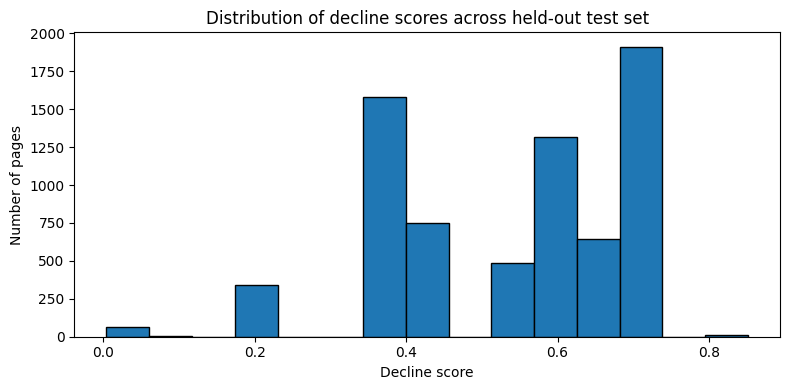

Saved figure to work/figures/w07_score_distribution.png


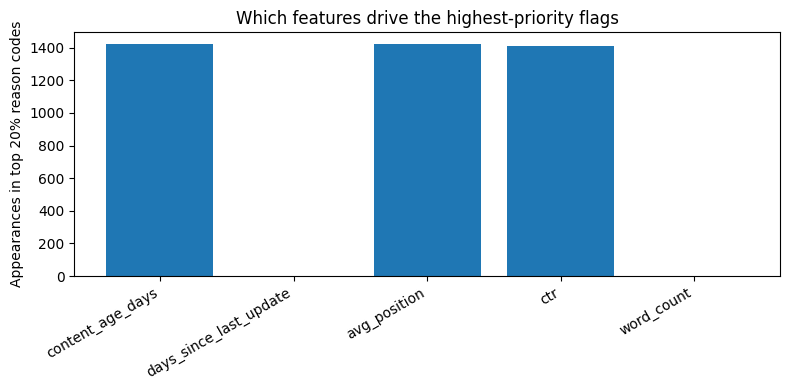

Saved figure to work/figures/w07_top_drivers.png


In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import json
import matplotlib.pyplot as plt

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# 1. Export the ranked queue (stays out of git by design — regenerated each run)
queue_export_cols = ["rank", "content_id", "decline_score", "reason_code"]
queue[queue_export_cols].to_csv("work/outputs/w07_ranked_action_queue.csv", index=False)
print(f"Exported {len(queue)} ranked pages to work/outputs/w07_ranked_action_queue.csv")

# 2. Export metrics JSON — the receipts the paper's numbers trace back to
metrics = {
    "model": "DecisionTreeClassifier(max_depth=4, class_weight='balanced')",
    "features": features,
    "split": "GroupShuffleSplit by client_id, test_size=0.25, random_state=42",
    "week6_validated_precision": {
        "random_split_precision_at_20": 0.750,
        "random_split_precision_at_50": 0.800,
        "grouped_split_precision_at_20": 0.650,
        "grouped_split_precision_at_50": 0.600
    },
    "week7_queue_summary": {
        "total_pages_scored": int(len(queue)),
        "unique_score_values": int(queue["decline_score"].nunique()),
        "top_decline_score": float(queue["decline_score"].max())
    },
    "leakage_audit_note": "impressions_90d excluded — near-zero correlation (-0.018) with label, removing it did not hurt performance"
}
with open("work/outputs/w07_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Exported metrics to work/outputs/w07_metrics.json")

# 3. Figure: distribution of decline scores across the queue
plt.figure(figsize=(8, 4))
plt.hist(queue["decline_score"], bins=15, edgecolor="black")
plt.xlabel("Decline score")
plt.ylabel("Number of pages")
plt.title("Distribution of decline scores across held-out test set")
plt.tight_layout()
plt.savefig("work/figures/w07_score_distribution.png", dpi=150)
plt.show()
print("Saved figure to work/figures/w07_score_distribution.png")

# 4. Figure: top reason-code drivers (which features appear most in top 20% of queue)
top20 = queue.head(int(len(queue) * 0.2))
feature_mentions = {f: top20["reason_code"].str.contains(f).sum() for f in features}
plt.figure(figsize=(8, 4))
plt.bar(feature_mentions.keys(), feature_mentions.values())
plt.xticks(rotation=30, ha="right")
plt.ylabel("Appearances in top 20% reason codes")
plt.title("Which features drive the highest-priority flags")
plt.tight_layout()
plt.savefig("work/figures/w07_top_drivers.png", dpi=150)
plt.show()
print("Saved figure to work/figures/w07_top_drivers.png")


## Self-check

Before you submit, confirm each line honestly:

- [done ] Every section above is filled — markdown thinking AND the code that backs it
- [done ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [done ] No client names, URLs, or private queries anywhere
- [done ] My claims use careful words: observed, measured, directional, decision-support
- [done ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.